In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path # manage paths for the project

In [51]:
# define the path of the data
data_path = Path('..') / 'data' / 'raw' / 'educacionCol.csv'

In [52]:
# Cargar dataset

df = pd.read_csv(data_path, low_memory=False)
df.head()

,Código de la Institución,IES PADRE,Institución de Educación Superior (IES),Principal oSeccional,Id_Sector,Id_Caracter,Código del departamento(IES),Departamento de domicilio de la IES,Código del Municipio(IES),Municipio dedomicilio de la IES,...,Id_Nucleo,Núcleo Básico del Conocimiento (NBC),Código del Departamento(Programa),Departamento de oferta del programa,Código del Municipio(Programa),Municipio de oferta del programa,Id Género,Año,Semestre,Total Matriculados
0,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23670,SAN ANDRES DE SOTAVENTO,2,2015,1,2
1,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23670,SAN ANDRES DE SOTAVENTO,1,2015,1,2
2,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23672,SAN ANTERO,2,2015,1,9
3,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23672,SAN ANTERO,1,2015,1,1
4,2833,2833,CORPORACION UNIVERSITARIA REMINGTON,PRINCIPAL,2,3,5,ANTIOQUIA,5001,MEDELLIN,...,612,CONTADURIA PUBLICA,23,CORDOBA,23675,SAN BERNARDO DEL VIENTO,2,2015,1,18


In [53]:
df.tail()

,Código de la Institución,IES PADRE,Institución de Educación Superior (IES),Principal oSeccional,Id_Sector,Id_Caracter,Código del departamento(IES),Departamento de domicilio de la IES,Código del Municipio(IES),Municipio dedomicilio de la IES,...,Id_Nucleo,Núcleo Básico del Conocimiento (NBC),Código del Departamento(Programa),Departamento de oferta del programa,Código del Municipio(Programa),Municipio de oferta del programa,Id Género,Año,Semestre,Total Matriculados
390898,9935,9935,UNIDAD TECNOLÓGICA DEL MAGDALENA MEDIO - UTEM -,Principal,2,2,68,Santander,68081,Barrancabermeja,...,0,Sin clasificar,68,Santander,68081,Barrancabermeja,2,2021,1,21
390899,9936,9936,CORPORACIÓN UNIVERSITARIA AUTÓNOMA DEL NORTE,Principal,2,3,54,Norte De Santander,54001,San José De Cúcuta,...,611,Economía,54,Norte De Santander,54001,San José De Cúcuta,1,2021,1,1
390900,9936,9936,CORPORACIÓN UNIVERSITARIA AUTÓNOMA DEL NORTE,Principal,2,3,54,Norte De Santander,54001,San José De Cúcuta,...,611,Economía,54,Norte De Santander,54001,San José De Cúcuta,2,2021,1,6
390901,9936,9936,CORPORACIÓN UNIVERSITARIA AUTÓNOMA DEL NORTE,Principal,2,3,54,Norte De Santander,54001,San José De Cúcuta,...,0,Sin clasificar,54,Norte De Santander,54001,San José De Cúcuta,1,2021,1,1
390902,9936,9936,CORPORACIÓN UNIVERSITARIA AUTÓNOMA DEL NORTE,Principal,2,3,54,Norte De Santander,54001,San José De Cúcuta,...,0,Sin clasificar,54,Norte De Santander,54001,San José De Cúcuta,2,2021,1,8


In [54]:
# exploracion inicial
print(f"Dimensiones del dataset: {df.shape[0]} filas y {df.shape[1]} columnas \n")
df.info()

Dimensiones del dataset: 390903 filas y 26 columnas 

<class 'pandas.DataFrame'>
RangeIndex: 390903 entries, 0 to 390902
Data columns (total 26 columns):
 #   Column                                   Non-Null Count   Dtype
---  ------                                   --------------   -----
 0   Código de la Institución                 390903 non-null  int64
 1   IES PADRE                                390903 non-null  int64
 2   Institución de Educación Superior (IES)  390903 non-null  str  
 3   Principal oSeccional                     390903 non-null  str  
 4   Id_Sector                                390903 non-null  int64
 5   Id_Caracter                              390903 non-null  int64
 6   Código del departamento(IES)             390903 non-null  int64
 7   Departamento de domicilio de la IES      390903 non-null  str  
 8   Código del Municipio(IES)                390903 non-null  int64
 9   Municipio dedomicilio de la IES          390903 non-null  str  
 10  Código SNIES 

In [55]:
# Analisis de valores nulos

nulos = df.isnull().sum()
nulos_porcentaje = (nulos / len(df)) * 100
df_nulos = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': nulos_porcentaje})
print(df_nulos)

# Mostrar solo las columnas que tienen nulos
display(df_nulos[df_nulos['Nulos'] > 0].sort_values(by='Porcentaje (%)', ascending=False))

# No tenemos nulos

                                         Nulos  Porcentaje (%)
Código de la Institución                     0             0.0
IES PADRE                                    0             0.0
Institución de Educación Superior (IES)      0             0.0
Principal oSeccional                         0             0.0
Id_Sector                                    0             0.0
Id_Caracter                                  0             0.0
Código del departamento(IES)                 0             0.0
Departamento de domicilio de la IES          0             0.0
Código del Municipio(IES)                    0             0.0
Municipio dedomicilio de la IES              0             0.0
Código SNIES delprograma                     0             0.0
Programa Académico                           0             0.0
Id_Nivel                                     0             0.0
Id_Nivel_Formacion                           0             0.0
Id_Metodologia                               0         

,Nulos,Porcentaje (%)


In [56]:
total_duplicados = df.duplicated().sum()
print(f"Se encontraron {total_duplicados} filas exactamente duplicadas en el dataset.")

if total_duplicados > 0:
    # Mostrar una muestra de los duplicados
    display(df[df.duplicated(keep=False)].sort_values(by='Código SNIES delprograma').head(4))

Se encontraron 106599 filas exactamente duplicadas en el dataset.


,Código de la Institución,IES PADRE,Institución de Educación Superior (IES),Principal oSeccional,Id_Sector,Id_Caracter,Código del departamento(IES),Departamento de domicilio de la IES,Código del Municipio(IES),Municipio dedomicilio de la IES,...,Id_Nucleo,Núcleo Básico del Conocimiento (NBC),Código del Departamento(Programa),Departamento de oferta del programa,Código del Municipio(Programa),Municipio de oferta del programa,Id Género,Año,Semestre,Total Matriculados
195533,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,PRINCIPAL,1,4,11,BOGOTA D.C.,11001,BOGOTA D.C.,...,824,INGENIERIA AGRONOMICA PECUARIA Y AFINES,11,BOGOTA D.C.,11001,BOGOTA D.C.,2,2015,1,199
195534,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,PRINCIPAL,1,4,11,BOGOTA D.C.,11001,BOGOTA D.C.,...,824,INGENIERIA AGRONOMICA PECUARIA Y AFINES,11,BOGOTA D.C.,11001,BOGOTA D.C.,1,2015,1,438
8,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,PRINCIPAL,1,4,11,BOGOTA D.C.,11001,BOGOTA D.C.,...,824,INGENIERIA AGRONOMICA PECUARIA Y AFINES,11,BOGOTA D.C.,11001,BOGOTA D.C.,1,2015,1,438
6,1101,1101,UNIVERSIDAD NACIONAL DE COLOMBIA,PRINCIPAL,1,4,11,BOGOTA D.C.,11001,BOGOTA D.C.,...,824,INGENIERIA AGRONOMICA PECUARIA Y AFINES,11,BOGOTA D.C.,11001,BOGOTA D.C.,2,2015,1,199


In [57]:
# Validacion de tipos de datos
display(df.dtypes)

# Total de matriculados esta como texto hay que corregirlo

Código de la Institución                   int64
IES PADRE                                  int64
Institución de Educación Superior (IES)      str
Principal oSeccional                         str
Id_Sector                                  int64
Id_Caracter                                int64
Código del departamento(IES)               int64
Departamento de domicilio de la IES          str
Código del Municipio(IES)                  int64
Municipio dedomicilio de la IES              str
Código SNIES delprograma                   int64
Programa Académico                           str
Id_Nivel                                   int64
Id_Nivel_Formacion                         int64
Id_Metodologia                             int64
Id_Area                                      str
Id_Nucleo                                    str
Núcleo Básico del Conocimiento (NBC)         str
Código del Departamento(Programa)          int64
Departamento de oferta del programa          str
Código del Municipio

Total de Outliers: 48142


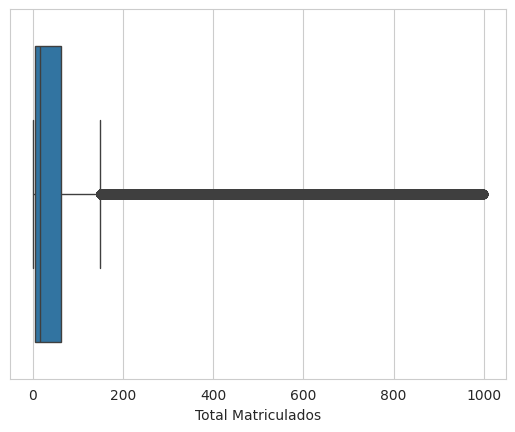

In [58]:
# 2. Forzar conversión a numérico, rellenar nulos con 0 y pasar a entero
df['Total Matriculados'] = pd.to_numeric(df['Total Matriculados'], errors='coerce').fillna(0).astype('int')

# --- Gráfico de Outliers ---
sns.boxplot(x=df['Total Matriculados'])

# --- Cuantificación de Outliers (Método IQR) ---
Q1 = df['Total Matriculados'].quantile(0.25)
Q3 = df['Total Matriculados'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
outliers = df[df['Total Matriculados'] > limite_superior]
print(f"Total de Outliers: {len(outliers)}")

In [59]:
# Revisar si hay municipios escritos de diferentes formas (Mayúsculas vs Minúsculas o espacios al final)
municipios_unicos = df['Municipio de oferta del programa'].dropna().unique()
print(f"Total municipios únicos (sin limpiar): {len(municipios_unicos)}")

# Aplicando strip y upper para ver si el número se reduce (lo que indicaría inconsistencias de formato)
municipios_limpios = df['Municipio de oferta del programa'].dropna().astype(str).str.strip().str.upper().unique()
print(f"Total municipios únicos (limpiando espacios y mayúsculas): {len(municipios_limpios)}")

# Verificar longitudes raras en los años (deberían ser 4 caracteres)
años_inconsistentes = df[df['Año'].astype(str).str.len() != 4]['Año'].unique()
if len(años_inconsistentes) > 0:
    print(f"Años con formato inconsistente encontrados: {años_inconsistentes}")
else:
    print("La columna 'Año' tiene un formato consistente (4 dígitos).")

Total municipios únicos (sin limpiar): 1439
Total municipios únicos (limpiando espacios y mayúsculas): 1004
La columna 'Año' tiene un formato consistente (4 dígitos).


/tmp/ipykernel_1485129/3999587787.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Estado', y='Cantidad', data=datos_clones, palette=['#e74c3c', '#2ecc71'])


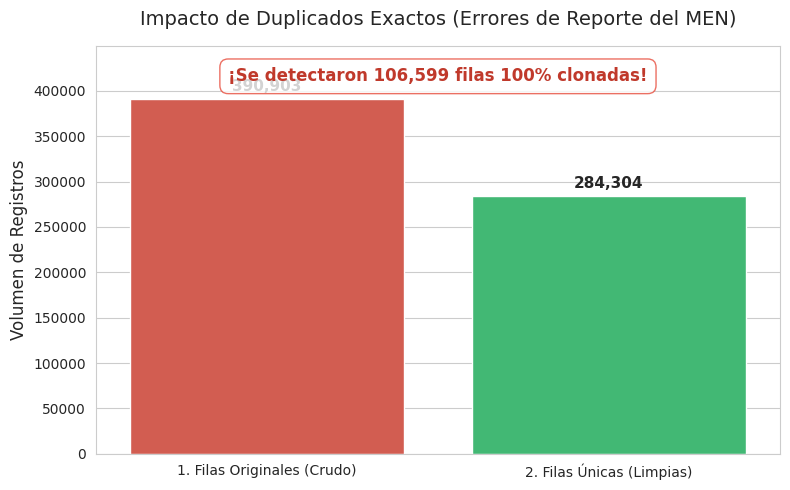

In [60]:
# Calcular dimensiones
total_filas = len(df)
filas_unicas = len(df.drop_duplicates())
duplicados_exactos = total_filas - filas_unicas

# Preparar datos para el gráfico
datos_clones = pd.DataFrame({
    'Estado': ['1. Filas Originales (Crudo)', '2. Filas Únicas (Limpias)'],
    'Cantidad': [total_filas, filas_unicas]
})

# Configurar estilo
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid")

# Crear gráfico de barras
ax = sns.barplot(x='Estado', y='Cantidad', data=datos_clones, palette=['#e74c3c', '#2ecc71'])

# Añadir etiquetas de datos encima de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Impacto de Duplicados Exactos (Errores de Reporte del MEN)', fontsize=14, pad=15)
plt.ylabel('Volumen de Registros', fontsize=12)
plt.xlabel('')
plt.ylim(0, total_filas * 1.15) # Dar espacio arriba para el texto

# Añadir nota explicativa dentro del gráfico
plt.text(0.5, total_filas * 1.05, f'¡Se detectaron {duplicados_exactos:,} filas 100% clonadas!',
            ha='center', color='#c0392b', fontweight='bold', fontsize=12,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='#e74c3c', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

/tmp/ipykernel_1485129/784732006.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Valores Únicos', y='Entidad / Dimensión', data=df_cardinalidad, palette='viridis')


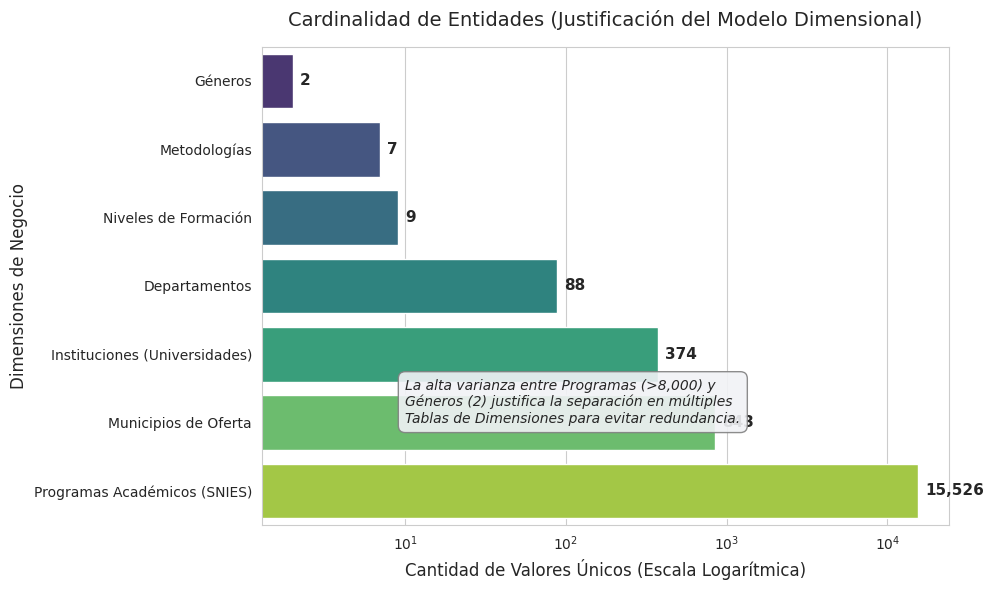

In [61]:
cardinalidad = {
        'Programas Académicos (SNIES)': df['Código SNIES delprograma'].nunique(),
        'Municipios de Oferta': df['Código del Municipio(Programa)'].nunique(),
        'Instituciones (Universidades)': df['Institución de Educación Superior (IES)'].nunique(),
        'Departamentos': df['Departamento de oferta del programa'].nunique(),
        'Niveles de Formación': df['Id_Nivel_Formacion'].nunique(),
        'Metodologías': df['Id_Metodologia'].nunique(),
        'Géneros': df['Id Género'].nunique()
}

# Convertir a DataFrame y ordenar de mayor a menor
df_cardinalidad = pd.DataFrame(list(cardinalidad.items()), columns=['Entidad / Dimensión', 'Valores Únicos'])
df_cardinalidad = df_cardinalidad.sort_values('Valores Únicos', ascending=True)

# Configurar gráfico
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Gráfico de barras horizontales (ideal para etiquetas largas)
ax = sns.barplot(x='Valores Únicos', y='Entidad / Dimensión', data=df_cardinalidad, palette='viridis')

# Añadir etiquetas de datos a la derecha de las barras
for p in ax.patches:
    ax.annotate(f'{int(p.get_width()):,}',
                (p.get_width(), p.get_y() + p.get_height() / 2.),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

# Escala logarítmica en el eje X para que los valores pequeños (Género=2) se vean junto a los gigantes (Programas=10,000)
plt.xscale('log')

plt.title('Cardinalidad de Entidades (Justificación del Modelo Dimensional)', fontsize=14, pad=15)
plt.xlabel('Cantidad de Valores Únicos (Escala Logarítmica)', fontsize=12)
plt.ylabel('Dimensiones de Negocio', fontsize=12)

# Añadir nota explicativa
nota = ("La alta varianza entre Programas (>8,000) y\n"
        "Géneros (2) justifica la separación en múltiples\n"
        "Tablas de Dimensiones para evitar redundancia.")
plt.text(10, 5, nota, fontsize=10, style='italic',
        bbox=dict(facecolor='#f1f2f6', alpha=0.9, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

In [62]:
# tranformacion temporal
df.columns = df.columns.str.lower()

In [63]:
text_colummns = df.select_dtypes(include=['object', 
                                        'string']).columns

for column in text_colummns:
    df[column] = df[column].str.lower()
    
df.head(100)

,código de la institución,ies padre,institución de educación superior (ies),principal oseccional,id_sector,id_caracter,código del departamento(ies),departamento de domicilio de la ies,código del municipio(ies),municipio dedomicilio de la ies,...,id_nucleo,núcleo básico del conocimiento (nbc),código del departamento(programa),departamento de oferta del programa,código del municipio(programa),municipio de oferta del programa,id género,año,semestre,total matriculados
0,2833,2833,corporacion universitaria remington,principal,2,3,5,antioquia,5001,medellin,...,612,contaduria publica,23,cordoba,23670,san andres de sotavento,2,2015,1,2
1,2833,2833,corporacion universitaria remington,principal,2,3,5,antioquia,5001,medellin,...,612,contaduria publica,23,cordoba,23670,san andres de sotavento,1,2015,1,2
2,2833,2833,corporacion universitaria remington,principal,2,3,5,antioquia,5001,medellin,...,612,contaduria publica,23,cordoba,23672,san antero,2,2015,1,9
3,2833,2833,corporacion universitaria remington,principal,2,3,5,antioquia,5001,medellin,...,612,contaduria publica,23,cordoba,23672,san antero,1,2015,1,1
4,2833,2833,corporacion universitaria remington,principal,2,3,5,antioquia,5001,medellin,...,612,contaduria publica,23,cordoba,23675,san bernardo del viento,2,2015,1,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1101,1101,universidad nacional de colombia,principal,1,4,11,bogota d.c.,11001,bogota d.c.,...,934,biologia microbiologia y afines,11,bogota d.c.,11001,bogota d.c.,2,2015,1,283
96,1101,1101,universidad nacional de colombia,principal,1,4,11,bogota d.c.,11001,bogota d.c.,...,934,biologia microbiologia y afines,11,bogota d.c.,11001,bogota d.c.,1,2015,1,318
97,1101,1101,universidad nacional de colombia,principal,1,4,11,bogota d.c.,11001,bogota d.c.,...,937,matematicas estadistica y afines,11,bogota d.c.,11001,bogota d.c.,2,2015,1,117
98,1101,1101,universidad nacional de colombia,principal,1,4,11,bogota d.c.,11001,bogota d.c.,...,937,matematicas estadistica y afines,11,bogota d.c.,11001,bogota d.c.,1,2015,1,262


In [64]:
df["departamento de domicilio de la ies"].unique()

<StringArray>
[                                               'antioquia',
                                              'bogota d.c.',
                                                    'cauca',
                                                   'narino',
                                                  'bolivar',
                                                  'quindío',
                                                'atlantico',
                                                   'caldas',
                                                'santander',
                                          'valle del cauca',
                                                'risaralda',
                                                    'sucre',
                                                    'huila',
                                                   'boyaca',
                                                   'tolima',
                                                  'cordoba',
          

In [65]:
df["departamento de oferta del programa"].unique()

<StringArray>
[                                                 'cordoba',
                                              'bogota d.c.',
                                             'cundinamarca',
                                                    'cauca',
                                                'antioquia',
                                                    'choco',
                                                    'huila',
                                               'la guajira',
                                                'magdalena',
                                                   'narino',
                                                  'bolívar',
                                          'valle del cauca',
                                                'atlantico',
                                                   'caldas',
                                                     'meta',
                                       'norte de santander',
          

In [66]:
df["id género"].unique() # por si depronto hay valores que no sean 1 y 2

array([2, 1])

# Profiling del Dataset de la API — Créditos Otorgados (ICETEX)

Perfilado de la fuente complementaria: **Créditos Otorgados por ICETEX** desde la API Socrata de `datos.gov.co` (resource ID: `26bn-e42j`).
Cubre: análisis de nulos, duplicados, validación de tipos, outliers, formatos inconsistentes y compatibilidad cruzada con el dataset primario.

In [67]:
import requests

# Cargar datos de ICETEX directamente desde la API Socrata (datos.gov.co)
SOCRATA_ENDPOINT = "https://www.datos.gov.co/resource/26bn-e42j.json"

registros = []
limit = 50000
offset = 0

while True:
    params = {"$limit": limit, "$offset": offset}
    response = requests.get(SOCRATA_ENDPOINT, params=params)
    response.raise_for_status()
    batch = response.json()
    if not batch:
        break
    registros.extend(batch)
    offset += limit
    print(f"   Descargados {len(registros):,} registros...")

df_icetex = pd.DataFrame(registros)
print(f"\nTotal descargado: {df_icetex.shape[0]:,} filas x {df_icetex.shape[1]} columnas")
df_icetex.head()

   Descargados 50,000 registros...
   Descargados 100,000 registros...
   Descargados 107,534 registros...

Total descargado: 107,534 filas x 13 columnas


,vigencia,periodo_otorgamiento,sexo_al_nacer,estrato_socio_economico,codigo_dedepartamento_de,departamento_de_origen,categoria_del_municipio_de,sector_ies,nivel_de_formacion,modalidad_de_linea,modalidad_del_credito,rango_del_valor_total,numero_de_nuevos_beneficiarios
0,2015,2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formación técnica profesional,PREGRADO,MATRICULA,I,1
1,2015,2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formación técnica profesional,PREGRADO,MATRICULA,IV,1
2,2015,2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Formación técnica profesional,PREGRADO,MATRICULA,V,2
3,2015,2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Tecnológico,PREGRADO,SOSTENIMIENTO,I,1
4,2015,2015-1,Femenino,1,5,ANTIOQUIA,CIUDADES Y AGLOMERACIONES,OFICIAL,Universitario,PREGRADO,MATRICULA,I,5


In [68]:
# Dimensiones y tipos de datos iniciales
print(f"Dimensiones: {df_icetex.shape[0]:,} filas x {df_icetex.shape[1]} columnas\n")
df_icetex.info()

Dimensiones: 107,534 filas x 13 columnas

<class 'pandas.DataFrame'>
RangeIndex: 107534 entries, 0 to 107533
Data columns (total 13 columns):
 #   Column                          Non-Null Count   Dtype
---  ------                          --------------   -----
 0   vigencia                        107534 non-null  str  
 1   periodo_otorgamiento            107534 non-null  str  
 2   sexo_al_nacer                   107534 non-null  str  
 3   estrato_socio_economico         107534 non-null  str  
 4   codigo_dedepartamento_de        107534 non-null  str  
 5   departamento_de_origen          107534 non-null  str  
 6   categoria_del_municipio_de      107534 non-null  str  
 7   sector_ies                      107534 non-null  str  
 8   nivel_de_formacion              107534 non-null  str  
 9   modalidad_de_linea              107534 non-null  str  
 10  modalidad_del_credito           107534 non-null  str  
 11  rango_del_valor_total           107534 non-null  str  
 12  numero_de_nue

In [69]:
# Análisis de valores nulos por columna
nulos_icetex = df_icetex.isnull().sum()
nulos_pct = (nulos_icetex / len(df_icetex)) * 100
df_nulos_icetex = pd.DataFrame({'Nulos': nulos_icetex, 'Porcentaje (%)': nulos_pct.round(2)})

print("=== Valores nulos por columna ===")
display(df_nulos_icetex)

# Visualización de nulos
cols_con_nulos = df_nulos_icetex[df_nulos_icetex['Nulos'] > 0]
if cols_con_nulos.empty:
    print("\n✅ No se encontraron valores nulos en ninguna columna.")
else:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=cols_con_nulos.index, y=cols_con_nulos['Porcentaje (%)'], palette='Reds_r')
    plt.title('Porcentaje de Nulos por Columna (ICETEX)', fontsize=14)
    plt.ylabel('% Nulos')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

=== Valores nulos por columna ===


,Nulos,Porcentaje (%)
vigencia,0,0.0
periodo_otorgamiento,0,0.0
sexo_al_nacer,0,0.0
estrato_socio_economico,0,0.0
codigo_dedepartamento_de,0,0.0
departamento_de_origen,0,0.0
categoria_del_municipio_de,0,0.0
sector_ies,0,0.0
nivel_de_formacion,0,0.0
modalidad_de_linea,0,0.0



✅ No se encontraron valores nulos en ninguna columna.


In [70]:
# Detección de duplicados
duplicados_exactos = df_icetex.duplicated().sum()
print(f"Duplicados exactos (todas las columnas): {duplicados_exactos:,}")

# Duplicados por las columnas que conformarían el grano analítico del dataset
cols_grano = ['vigencia', 'periodo_otorgamiento', 'sexo_al_nacer',
              'estrato_socio_economico', 'departamento_de_origen',
              'sector_ies', 'nivel_de_formacion', 'modalidad_de_linea',
              'modalidad_del_credito', 'rango_del_valor_total']

duplicados_grano = df_icetex.duplicated(subset=cols_grano).sum()
print(f"Duplicados por grano analítico ({len(cols_grano)} columnas clave): {duplicados_grano:,}")

if duplicados_exactos > 0:
    print(f"\n⚠️ Muestra de filas duplicadas:")
    display(df_icetex[df_icetex.duplicated(keep=False)].sort_values(cols_grano[:3]).head(6))

Duplicados exactos (todas las columnas): 0
Duplicados por grano analítico (10 columnas clave): 31,214


## Validación de tipos de datos

La API Socrata devuelve **todo como string** (JSON). Verificamos que los campos numéricos sean convertibles y que los formatos de texto sean consistentes.

In [71]:
# Validación de VIGENCIA: ¿se puede castear a entero directamente?
print("=== VIGENCIA ===")
print(f"Valores únicos: {df_icetex['vigencia'].nunique()}")
print(f"Muestra: {df_icetex['vigencia'].unique()[:10]}")

# Intentar conversión a int
vigencia_numeric = pd.to_numeric(df_icetex['vigencia'], errors='coerce')
fallidos_vigencia = vigencia_numeric.isna().sum()
print(f"Registros que NO se pueden convertir a numérico: {fallidos_vigencia}")
print(f"Rango: {vigencia_numeric.min():.0f} - {vigencia_numeric.max():.0f}")

print("\n=== PERIODO OTORGAMIENTO ===")
print(f"Valores únicos: {df_icetex['periodo_otorgamiento'].nunique()}")
print(f"Todos los valores: {sorted(df_icetex['periodo_otorgamiento'].unique())}")

# Verificar formato YYYY-S (año-semestre)
import re
patron_periodo = df_icetex['periodo_otorgamiento'].str.match(r'^\d{4}-\d$')
no_match = (~patron_periodo).sum()
print(f"Registros que NO cumplen el patrón YYYY-S: {no_match}")

print("\n=== NÚMERO DE NUEVOS BENEFICIARIOS ===")
beneficiarios = pd.to_numeric(df_icetex['numero_de_nuevos_beneficiarios'], errors='coerce')
fallidos_benef = beneficiarios.isna().sum()
print(f"Registros que NO se pueden convertir a numérico: {fallidos_benef}")
print(f"Rango: {beneficiarios.min():.0f} - {beneficiarios.max():.0f}")
print(f"Media: {beneficiarios.mean():.2f} | Mediana: {beneficiarios.median():.0f}")

print("\n=== ESTRATO SOCIOECONÓMICO ===")
estrato = pd.to_numeric(df_icetex['estrato_socio_economico'], errors='coerce')
fallidos_estrato = estrato.isna().sum()
print(f"Registros que NO se pueden convertir a numérico: {fallidos_estrato}")
print(f"Valores únicos: {sorted(estrato.dropna().unique())}")
fuera_rango = ((estrato < 1) | (estrato > 6)).sum()
print(f"Registros fuera del rango [1..6]: {fuera_rango}")

=== VIGENCIA ===
Valores únicos: 11
Muestra: <StringArray>
['2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
 '2024']
Length: 10, dtype: str
Registros que NO se pueden convertir a numérico: 0
Rango: 2015 - 2025

=== PERIODO OTORGAMIENTO ===
Valores únicos: 21
Todos los valores: ['2015-1', '2015-2', '2016-1', '2016-2', '2017-1', '2017-2', '2018-1', '2018-2', '2019-1', '2019-2', '2020-1', '2020-2', '2021-1', '2021-2', '2022-1', '2022-2', '2023-1', '2023-2', '2024-1', '2024-2', '2025-1']
Registros que NO cumplen el patrón YYYY-S: 0

=== NÚMERO DE NUEVOS BENEFICIARIOS ===
Registros que NO se pueden convertir a numérico: 0
Rango: 1 - 668
Media: 4.65 | Mediana: 1

=== ESTRATO SOCIOECONÓMICO ===
Registros que NO se pueden convertir a numérico: 0
Valores únicos: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Registros fuera del rango [1..6]: 0


## Valores únicos y distribución de columnas categóricas

Inspección de los dominios de cada variable categórica para construir los diccionarios de homologación con el dataset primario.

In [72]:
# Valores únicos de todas las columnas categóricas relevantes
cols_categoricas = ['sexo_al_nacer', 'sector_ies', 'nivel_de_formacion',
                    'modalidad_de_linea', 'modalidad_del_credito',
                    'categoria_del_municipio_de', 'rango_del_valor_total',
                    'departamento_de_origen']

for col in cols_categoricas:
    print(f"\n{'='*60}")
    print(f"  {col.upper()}  ({df_icetex[col].nunique()} valores únicos)")
    print(f"{'='*60}")
    display(df_icetex[col].value_counts())


  SEXO_AL_NACER  (3 valores únicos)


sexo_al_nacer
Femenino       55084
Masculino      52436
Intersexual       14
Name: count, dtype: int64


  SECTOR_IES  (3 valores únicos)


sector_ies
PRIVADO    72341
OFICIAL    26009
N/A         9184
Name: count, dtype: int64


  NIVEL_DE_FORMACION  (11 valores únicos)


...

categoria_del_municipio_de
CIUDADES Y AGLOMERACIONES    61645
INTERMEDIO                   22859
RURAL                        14659
RURAL DISPERSO                8371
Name: count, dtype: int64


  RANGO_DEL_VALOR_TOTAL  (5 valores únicos)


rango_del_valor_total
I      27246
II     21412
III    20909
IV     19561
V      18406
Name: count, dtype: int64


  DEPARTAMENTO_DE_ORIGEN  (33 valores únicos)


departamento_de_origen
BOGOTÁ, D.C.                                                7549
ANTIOQUIA                                                   6682
VALLE DEL CAUCA                                             6529
SANTANDER                                                   6169
CUNDINAMARCA                                                5409
BOYACÁ                                                      5111
NARIÑO                                                      5062
BOLÍVAR                                                     5060
CÓRDOBA                                                     4871
TOLIMA                                                      4590
SUCRE                                                       4517
ATLÁNTICO                                                   4486
HUILA                                                       4097
MAGDALENA                                                   3648
CALDAS                                                      3544
NO

## Detección de outliers — Número de nuevos beneficiarios

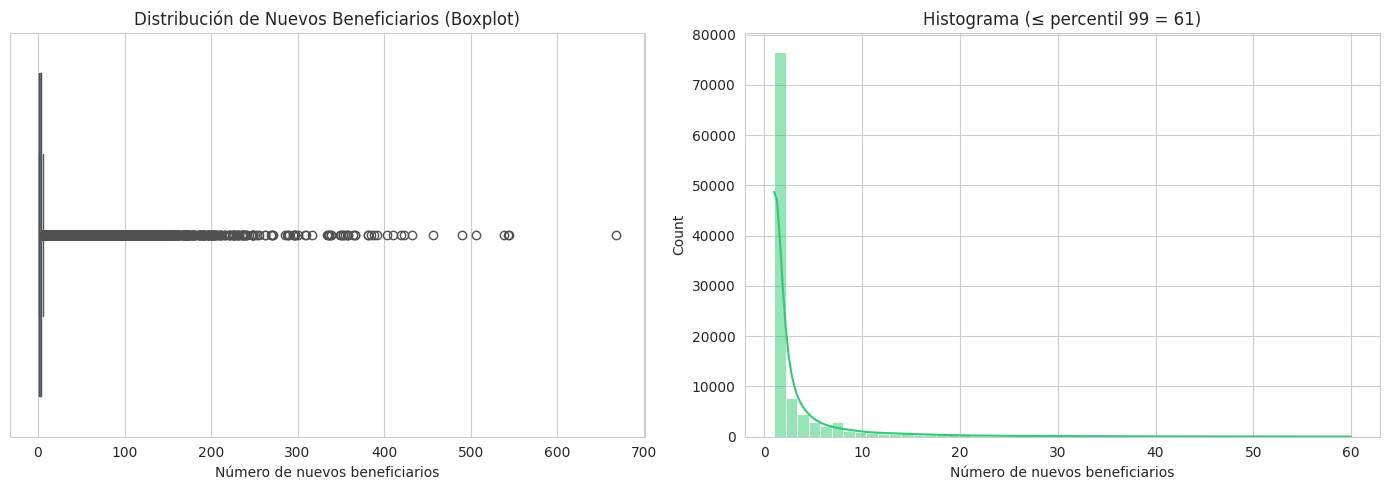


Q1=1, Q3=3, IQR=2, Límite superior=6
Total de outliers (IQR): 13,514 (12.6%)
Valor máximo: 668


In [73]:
# Outliers en la métrica principal (número de nuevos beneficiarios)
beneficiarios = pd.to_numeric(df_icetex['numero_de_nuevos_beneficiarios'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(x=beneficiarios, ax=axes[0], color='#3498db')
axes[0].set_title('Distribución de Nuevos Beneficiarios (Boxplot)', fontsize=12)
axes[0].set_xlabel('Número de nuevos beneficiarios')

# Histograma (sin outliers extremos para visualización)
p99 = beneficiarios.quantile(0.99)
sns.histplot(beneficiarios[beneficiarios <= p99], bins=50, ax=axes[1], color='#2ecc71', kde=True)
axes[1].set_title(f'Histograma (≤ percentil 99 = {p99:.0f})', fontsize=12)
axes[1].set_xlabel('Número de nuevos beneficiarios')

plt.tight_layout()
plt.show()

# Cuantificación IQR
Q1 = beneficiarios.quantile(0.25)
Q3 = beneficiarios.quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR
outliers_icetex = beneficiarios[beneficiarios > limite_superior]
print(f"\nQ1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}, Límite superior={limite_superior:.0f}")
print(f"Total de outliers (IQR): {len(outliers_icetex):,} ({len(outliers_icetex)/len(beneficiarios)*100:.1f}%)")
print(f"Valor máximo: {beneficiarios.max():,.0f}")

## Detección de formatos inconsistentes

Comparación de los departamentos del dataset ICETEX contra los departamentos canónicos del dataset primario (post-homologación).

In [74]:
# Departamentos canónicos del primario (33 oficiales post-homologación en transform.py)
deptos_canonicos = {
    'amazonas', 'antioquia', 'arauca', 'atlantico', 'bogota d.c.',
    'bolivar', 'boyaca', 'caldas', 'caqueta', 'casanare', 'cauca',
    'cesar', 'choco', 'cordoba', 'cundinamarca', 'guainia', 'guaviare',
    'huila', 'la guajira', 'magdalena', 'meta', 'narino',
    'norte de santander', 'putumayo', 'quindio', 'risaralda',
    'san andres y providencia', 'santander', 'sucre', 'tolima',
    'valle del cauca', 'vaupes', 'vichada'
}

# Normalizar los deptos de ICETEX para comparar (minúsculas, sin tildes)
import unicodedata

def quitar_tildes(texto):
    """Elimina tildes y diacríticos de un string"""
    nfkd = unicodedata.normalize('NFKD', texto)
    return ''.join(c for c in nfkd if not unicodedata.combining(c))

deptos_icetex = df_icetex['departamento_de_origen'].str.lower().str.strip().apply(quitar_tildes).unique()
deptos_icetex_set = set(deptos_icetex)

# Departamentos de ICETEX que NO están en los canónicos
sin_match = deptos_icetex_set - deptos_canonicos
print(f"Departamentos de ICETEX: {len(deptos_icetex_set)}")
print(f"Departamentos canónicos (primario): {len(deptos_canonicos)}")
print(f"\n⚠️ Departamentos de ICETEX SIN match en los canónicos ({len(sin_match)}):")
for d in sorted(sin_match):
    conteo = df_icetex[df_icetex['departamento_de_origen'].str.lower().str.strip().apply(quitar_tildes) == d].shape[0]
    print(f"   '{d}' → {conteo:,} registros")

# Departamentos canónicos SIN presencia en ICETEX
sin_icetex = deptos_canonicos - deptos_icetex_set
print(f"\nDepartamentos canónicos SIN presencia en ICETEX ({len(sin_icetex)}):")
for d in sorted(sin_icetex):
    print(f"   '{d}'")

Departamentos de ICETEX: 33
Departamentos canónicos (primario): 33

⚠️ Departamentos de ICETEX SIN match en los canónicos (2):
   'archipielago de san andres, providencia y santa catalina' → 527 registros
   'bogota, d.c.' → 7,549 registros

Departamentos canónicos SIN presencia en ICETEX (2):
   'bogota d.c.'
   'san andres y providencia'


In [75]:
# Comparación de NIVEL DE FORMACIÓN entre ambas fuentes
# Los niveles del primario (post-transform) vs los de ICETEX
print("=== NIVEL DE FORMACIÓN en ICETEX ===")
niveles_icetex = df_icetex['nivel_de_formacion'].unique()
for n in sorted(niveles_icetex):
    print(f"   '{n}'")

# Los niveles del primario se obtienen de las columnas Id_Nivel_Formacion del raw
# Valores esperados del transform.py del primario (basados en el schema original):
niveles_primario = [
    'tecnica profesional', 'tecnologica', 'universitaria',
    'especializacion', 'maestria', 'doctorado'
]
print(f"\n=== NIVEL DE FORMACIÓN esperados en el primario (post-transform) ===")
for n in niveles_primario:
    print(f"   '{n}'")

print(f"\n=== Diccionario de homologación necesario (ICETEX → Primario) ===")
for n in sorted(niveles_icetex):
    match = '??'
    n_lower = n.lower().strip()
    if 'técnica' in n_lower or 'tecnica' in n_lower:
        match = 'tecnica profesional'
    elif 'tecnol' in n_lower:
        match = 'tecnologica'
    elif 'universit' in n_lower:
        match = 'universitaria'
    elif 'especiali' in n_lower:
        match = 'especializacion'
    elif 'maestr' in n_lower:
        match = 'maestria'
    elif 'doctor' in n_lower:
        match = 'doctorado'
    print(f"   '{n}' → '{match}'")

=== NIVEL DE FORMACIÓN en ICETEX ===
   'Doctorado'
   'Especialización médico quirúrgica'
   'Especialización tecnológica'
   'Especialización técnico profesional'
   'Especialización universitaria'
   'Exterior'
   'Formación técnica profesional'
   'Maestría'
   'Normalista'
   'Tecnológico'
   'Universitario'

=== NIVEL DE FORMACIÓN esperados en el primario (post-transform) ===
   'tecnica profesional'
   'tecnologica'
   'universitaria'
   'especializacion'
   'maestria'
   'doctorado'

=== Diccionario de homologación necesario (ICETEX → Primario) ===
   'Doctorado' → 'doctorado'
   'Especialización médico quirúrgica' → 'especializacion'
   'Especialización tecnológica' → 'tecnologica'
   'Especialización técnico profesional' → 'especializacion'
   'Especialización universitaria' → 'universitaria'
   'Exterior' → '??'
   'Formación técnica profesional' → 'tecnica profesional'
   'Maestría' → 'maestria'
   'Normalista' → '??'
   'Tecnológico' → 'tecnologica'
   'Universitario' → 'u

## Compatibilidad cruzada entre fuentes

Verificamos qué porcentaje de las combinaciones `(año, semestre, departamento, nivel, sector, género)` del primario tienen correspondencia en ICETEX. Esto determina la cobertura del FULL OUTER JOIN.

In [76]:
# Preparar el primario al grano comparable (sin estrato ya que el primario no lo tiene)
# Usamos el df raw (antes de lowercase que se hizo arriba, recargamos)
df_prim = pd.read_csv(data_path, low_memory=False)

# Extraer año, semestre, depto, nivel, sector, género del primario
# El primario usa IDs numéricos para nivel y sector; mapeamos a texto
nivel_map_prim = {1: 'tecnica profesional', 2: 'tecnologica', 3: 'universitaria',
                  4: 'especializacion', 5: 'maestria', 6: 'doctorado'}
sector_map_prim = {1: 'oficial', 2: 'privado'}

prim_keys = pd.DataFrame({
    'anio': df_prim['Año'],
    'semestre': df_prim['Semestre'],
    'departamento': df_prim['Departamento de oferta del programa'].str.lower().str.strip().apply(quitar_tildes),
    'nivel': df_prim['Id_Nivel_Formacion'].map(nivel_map_prim),
    'sector': df_prim['Id_Sector'].map(sector_map_prim),
    'genero': df_prim['Id Género']
}).drop_duplicates()

# Preparar ICETEX al grano comparable
# Extraer año y semestre del periodo_otorgamiento
icetex_keys = pd.DataFrame({
    'anio': pd.to_numeric(df_icetex['vigencia']),
    'semestre': df_icetex['periodo_otorgamiento'].str.split('-').str[1].astype(int),
    'departamento': df_icetex['departamento_de_origen'].str.lower().str.strip().apply(quitar_tildes),
    'nivel': df_icetex['nivel_de_formacion'].str.lower().str.strip(),
    'sector': df_icetex['sector_ies'].str.lower().str.strip(),
    'genero': df_icetex['sexo_al_nacer'].map({'Femenino': 2, 'Masculino': 1})
}).drop_duplicates()

# Homologar nivel de ICETEX para comparación justa
nivel_homolog = {
    'formación técnica profesional': 'tecnica profesional',
    'tecnológico': 'tecnologica', 'tecnologico': 'tecnologica',
    'universitario': 'universitaria',
    'especialización': 'especializacion', 'especializacion': 'especializacion',
    'maestría': 'maestria', 'maestria': 'maestria',
    'doctorado': 'doctorado'
}
icetex_keys['nivel'] = icetex_keys['nivel'].map(nivel_homolog)

# Calcular intersección
prim_set = set(prim_keys.dropna().itertuples(index=False, name=None))
icetex_set = set(icetex_keys.dropna().itertuples(index=False, name=None))
interseccion = prim_set & icetex_set

print(f"Combinaciones únicas en primario:  {len(prim_set):,}")
print(f"Combinaciones únicas en ICETEX:    {len(icetex_set):,}")
print(f"Intersección (match directo):      {len(interseccion):,}")
print(f"\nCobertura del primario por ICETEX: {len(interseccion)/len(prim_set)*100:.1f}%")
print(f"Cobertura de ICETEX por primario:  {len(interseccion)/len(icetex_set)*100:.1f}%")

# Rango temporal de cada fuente
print(f"\nRango temporal primario: {df_prim['Año'].min()} - {df_prim['Año'].max()}")
print(f"Rango temporal ICETEX:   {pd.to_numeric(df_icetex['vigencia']).min():.0f} - {pd.to_numeric(df_icetex['vigencia']).max():.0f}")

Combinaciones únicas en primario:  4,781
Combinaciones únicas en ICETEX:    7,755
Intersección (match directo):      2,232

Cobertura del primario por ICETEX: 46.7%
Cobertura de ICETEX por primario:  28.8%

Rango temporal primario: 2015 - 2021
Rango temporal ICETEX:   2015 - 2025


## Resumen de hallazgos de calidad — ICETEX

**Problemas identificados que impactan `clean_icetex` y la suite Great Expectations:**

1. **Todos los campos vienen como `str`** (efecto de la API Socrata JSON). Requiere casteo explícito de: `vigencia` → int, `estrato_socio_economico` → int, `numero_de_nuevos_beneficiarios` → int.

2. **`vigencia` desde la API viene SIN coma de miles** (ej. `"2015"`, no `"2,015"` como el CSV descargado). El casteo a int es directo.

3. **Homologación de `nivel_de_formacion`**: ICETEX usa nombres descriptivos (`"Formación técnica profesional"`, `"Tecnológico"`, `"Universitario"`, `"Especialización"`, `"Maestría"`, `"Doctorado"`) que deben mapearse a los canónicos del primario (`tecnica profesional`, `tecnologica`, `universitaria`, `especializacion`, `maestria`, `doctorado`).

4. **Homologación de `sector_ies`**: ICETEX usa `"OFICIAL"` / `"PRIVADO"` (mayúsculas); el primario usa `"oficial"` / `"privado"` (minúsculas post-transform).

5. **Homologación de `departamento_de_origen`**: ICETEX usa nombres en MAYÚSCULAS (`"ANTIOQUIA"`); el primario los tiene en minúsculas sin tildes. Se debe aplicar `.lower().strip()` + `quitar_tildes()` + el diccionario `mapa_deptos` ya existente en `transform.py`.

6. **Mapeo de `sexo_al_nacer`**: `"Femenino"` → `id_genero=2`, `"Masculino"` → `id_genero=1`.

7. **`estrato_socio_economico`**: verificar si el rango es {1..6} estrictamente o si hay valores atípicos (ej. 0).

8. **Semántica del departamento**: en el primario es "departamento de oferta del programa"; en ICETEX es "departamento de origen (nacimiento) del beneficiario". Se tratan como proxy único ("departamento asociado al estudiante") bajo el supuesto de movilidad limitada. **Documentar como assumption crítica.**

9. **Rango temporal**: verificar la intersección de años entre ambas fuentes. Filas sin match temporal quedan con métrica 0 en el full outer join.

10. **Columnas descartables de ICETEX** (no usadas en el fact integrado): `categoria_del_municipio_de`, `modalidad_de_linea`, `modalidad_del_credito`, `rango_del_valor_total`, `codigo_dedepartamento_de`. Se agregan y se pierden al hacer groupby al grano común.